# Imports

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
import csv
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
import numpy as np

from torchvision import models


# Configuration

In [ ]:
@dataclass
class CFG:

    # données
    data_dir: str = "./data"

    # critère de perte 
    mse_weight = 1.0
    feature_weight = 0.1
    style_weight = 0.05
    vgg_resize = 64
    layer = "relu2_2"

    #modèle
    base_ch = 64
    gn_groups = 8
        
    #entrainement
    batch_size: int = 256
    num_workers: int = 0
    epochs: int = 100
    lr: float = 3e-3
    weight_decay: float = 0.0
    seed: int = 42

    # bruit
    noises: tuple = ("gaussian", "speckle")
    split_mode: str = "half"
    gaussian_std: float = 0.12
    speckle_std: float = 0.35

    # sauvegardes
    out_dir: str = "./out_cifar10_denoise"
    model_path: str = "denoiser_cifar10.pt"
    losses_path: str = "losses.csv"
    examples_path: str = "cifar10_examples.pt"


cfg = CFG()

def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True  # perf
set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs(cfg.out_dir, exist_ok=True)
cfg.model_path = os.path.join(cfg.out_dir, cfg.model_path)
cfg.losses_path = os.path.join(cfg.out_dir, cfg.losses_path)
cfg.examples_path = os.path.join(cfg.out_dir, cfg.examples_path)


Device: cuda


# Dataset wrapper

In [ ]:

class NoisedCIFAR10(Dataset):
    """
    Retourne: (x_noisy, x_clean, y)
    x_clean et x_noisy: float32 [0,1], shape (3,32,32)
    """
    def __init__(self, base_ds,
        noises=("gaussian", "speckle"),
        split_mode="half",
        gaussian_std=0.12,
        speckle_std=0.35,
        deterministic=False):
        self.base = base_ds
        self.noises = noises
        self.split_mode = split_mode
        self.split = len(base_ds) // 2
        self.gaussian_std = gaussian_std
        self.speckle_std = speckle_std
        self.deterministic = deterministic

    
    @torch.no_grad()
    def add_noise(self, x, noise_type: str, seed=None):

        if seed is not None:
            g = torch.Generator(device=x.device)
            g.manual_seed(int(seed))

            if noise_type == "gaussian":
                n = torch.randn(
                    x.size(),
                    generator=g,
                    device=x.device,
                    dtype=x.dtype
                ) * self.gaussian_std
                return (x + n).clamp(0, 1)

            if noise_type == "speckle":
                n = torch.randn(
                    x.size(),
                    generator=g,
                    device=x.device,
                    dtype=x.dtype
                ) * self.speckle_std
                return (x + x * n).clamp(0, 1)

        else:
            if noise_type == "gaussian":
                n = torch.randn_like(x) * self.gaussian_std
                return (x + n).clamp(0, 1)

            if noise_type == "speckle":
                n = torch.randn_like(x) * self.speckle_std
                return (x + x * n).clamp(0, 1)

        raise ValueError(noise_type)



    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):

        x_clean, y = self.base[idx]  # tensor [0,1]
        if self.split_mode == "half":
            noise_type = self.noises[0] if idx < self.split else self.noises[1]
        elif self.split_mode == "random":
            noise_type = random.choice(self.noises)
        else:
            raise ValueError("split_mode must be 'half' or 'random'")

        seed = idx if self.deterministic else None
        x_noisy = self.add_noise(x_clean, noise_type, seed=seed)
        return x_noisy, x_clean, y



# Modèle U-Net

In [ ]:
class DoubleConvGN(nn.Module):
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        if out_ch % groups != 0:
            raise ValueError(f"out_ch={out_ch} must be divisible by groups={groups}")
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)



class UNetLightGNResidual(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base_ch=64, gn_groups=8):
        super().__init__()

        Conv = lambda a,b: DoubleConvGN(a,b,groups=gn_groups)

        # Encoder
        self.enc1 = Conv(in_ch, base_ch)        # 32x32
        self.enc2 = Conv(base_ch, base_ch*2)    # 16x16
        self.enc3 = Conv(base_ch*2, base_ch*4)  # 8x8

        # Bottleneck (4x4)
        self.bottleneck = Conv(base_ch*4, base_ch*8)

        # Decoder
        self.dec3 = Conv(base_ch*8 + base_ch*4, base_ch*4)  # 8x8
        self.dec2 = Conv(base_ch*4 + base_ch*2, base_ch*2)  # 16x16
        self.dec1 = Conv(base_ch*2 + base_ch, base_ch)      # 32x32

        # Output residual
        self.out = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e3, 2))

        # Decoder
        d3 = F.interpolate(b, scale_factor=2, mode="nearest")
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = F.interpolate(d3, scale_factor=2, mode="nearest")
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = F.interpolate(d2, scale_factor=2, mode="nearest")
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        # Residual output
        r = self.out(d1)
        return x + r





# Création du dataset

In [ ]:
tfm = transforms.ToTensor()

train_base = datasets.CIFAR10(cfg.data_dir, train=True, download=True, transform=tfm)
test_base  = datasets.CIFAR10(cfg.data_dir, train=False, download=True, transform=tfm)

train_ds = NoisedCIFAR10(
    train_base,
    noises=cfg.noises,
    split_mode=cfg.split_mode,
    gaussian_std=cfg.gaussian_std,
    speckle_std=cfg.speckle_std,
    deterministic=False,
)
test_ds = NoisedCIFAR10(
    test_base,
    noises=cfg.noises,
    split_mode=cfg.split_mode,
    gaussian_std=cfg.gaussian_std,
    speckle_std=cfg.speckle_std,
    deterministic=True,
)

pin_memory = (device.type == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)


C:\Users\thoma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Train Utils

In [ ]:
@torch.no_grad()
def psnr_from_mse(mse):
    # PSNR = 10 log10( MAX^2 / MSE ), MAX=1
    return 10.0 * torch.log10(1.0 / torch.clamp(mse, min=1e-12))

@torch.no_grad()
def eval_on_loader(model, loader, criterion, device):
    model.eval()
    total_loss, n_batches = 0.0, 0
    for noisy, clean, _ in loader:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)
        out = model(noisy)
        loss = criterion(out, clean)
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


mse_metric = nn.MSELoss()

@torch.no_grad()
def eval_mse_psnr(model, loader, device):
    model.eval()
    mse_sum, n_batches = 0.0, 0
    mse_metric = nn.MSELoss()
    for noisy, clean, _ in loader:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)
        out = model(noisy).clamp(0,1)
        mse = mse_metric(out, clean)
        mse_sum += mse.item()
        n_batches += 1
    mse_avg = mse_sum / max(n_batches, 1)
    psnr = 10.0 * np.log10(1.0 / max(mse_avg, 1e-12))
    return mse_avg, psnr



# VGG16 Feature extractor

In [ ]:
def make_vgg16_feature_extractor(layer="relu2_2", device="cuda"):
    """
    Retourne un nn.Module qui sort les features à une couche VGG16 donnée.
    Entrée attendue: images RGB normalisées ImageNet.
    """
    vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features

    
    # Mapping couche -> index dans vgg.features
    # VGG16 features indices (conv/relu/pool):
    # relu1_1: 1, relu1_2: 3, pool1: 4
    # relu2_1: 6, relu2_2: 8, pool2: 9
    # relu3_1: 11, relu3_2: 13, relu3_3: 15, pool3: 16
    # relu4_1: 18, relu4_2: 20, relu4_3: 22, pool4: 23
    # relu5_1: 25, relu5_2: 27, relu5_3: 29, pool5: 30
    layer_to_idx = {
        "relu1_1": 1, "relu1_2": 3,
        "relu2_1": 6, "relu2_2": 8,
        "relu3_1": 11, "relu3_2": 13, "relu3_3": 15,
        "relu4_1": 18, "relu4_2": 20, "relu4_3": 22,
        "relu5_1": 25, "relu5_2": 27, "relu5_3": 29,
    }
    if layer not in layer_to_idx:
        raise ValueError(f"Unknown layer {layer}. Choose one of: {list(layer_to_idx.keys())}")

    cut_idx = layer_to_idx[layer]
    extractor = nn.Sequential(*[vgg[i] for i in range(cut_idx + 1)])

    # geler les poids
    for p in extractor.parameters():
        p.requires_grad = False

    extractor.eval().to(device)
    return extractor


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)


# Gradient descent criterion

In [ ]:

class DenoisingLoss(nn.Module):
    def __init__(self, feature_extractor, device,
        mse_weight=1.0, feature_weight=0.1, style_weight=0.1,
        vgg_resize=64):
        super().__init__()
        self.mse_weight = mse_weight
        self.feature_weight = feature_weight
        self.style_weight = style_weight
        self.mse_loss = nn.MSELoss()
        self.feature_extractor = feature_extractor
        self.device = device
        self.vgg_resize = vgg_resize


        self.feature_extractor.eval()
        for p in self.feature_extractor.parameters():
            p.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406], device=self.device).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225], device=self.device).view(1,3,1,1))

    def preprocess_for_vgg(self, x):
        # x: (B,3,H,W) in [0,1]
        x = nn.functional.interpolate(x, size=(self.vgg_resize, self.vgg_resize),
                                    mode="bilinear", align_corners=False)
        x = (x - self.mean) / self.std
        return x

    def gram_matrix(self, features):
        features = features.float()
        b, c, h, w = features.size()
        f = features.view(b, c, h*w)
        gram = torch.bmm(f, f.transpose(1, 2)) / (c * h * w)
        return gram


    def forward(self, output, target):

        output = output.clamp(0, 1)
        mse = self.mse_loss(output, target)

        # do VGG + style in fp32 to avoid fp16 overflow
        with torch.amp.autocast("cuda", enabled=False):
            out_vgg = self.preprocess_for_vgg(output.float())
            tgt_vgg = self.preprocess_for_vgg(target.float())

            with torch.no_grad():
                tgt_feat = self.feature_extractor(tgt_vgg)
            out_feat = self.feature_extractor(out_vgg)

            feature_loss = self.mse_loss(out_feat, tgt_feat)

            tgt_gram = self.gram_matrix(tgt_feat)
            out_gram = self.gram_matrix(out_feat)
            style_loss = self.mse_loss(out_gram, tgt_gram)

        total = (self.mse_weight * mse +
                self.feature_weight * feature_loss +
                self.style_weight * style_loss)
        return total


# Training

In [10]:
model = UNetLightGNResidual(base_ch=cfg.base_ch, gn_groups=cfg.gn_groups).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {params/1e6:.2f} M")

feature_extractor = make_vgg16_feature_extractor(cfg.layer, device=device)
feature_extractor = feature_extractor.to(device).eval()
for p in feature_extractor.parameters():
    p.requires_grad = False

criterion = DenoisingLoss(feature_extractor=feature_extractor, mse_weight=cfg.mse_weight, feature_weight=cfg.feature_weight, style_weight=cfg.style_weight, vgg_resize=cfg.vgg_resize, device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=1e-6)

use_amp = (device.type == "cuda")
#scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
use_amp = False
scaler = torch.amp.GradScaler("cuda", enabled=False)

losses_train = []
losses_test = []
psnr_test = []

best_test_loss = float("inf")
best_epoch = -1

# Path where the best checkpoint will be saved

best_ckpt_path = getattr(cfg, "best_ckpt_path", None)
if best_ckpt_path is None:
    out_dir = getattr(cfg, "out_dir", ".")
os.makedirs(out_dir, exist_ok=True)
best_ckpt_path = os.path.join(out_dir, "best_model.pt")

patience = 10

for epoch in range(cfg.epochs):
    model.train()
    running = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
    for noisy, clean, _ in pbar:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            out = model(noisy)
            loss = criterion(out, clean)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_train = running / len(train_loader)
    t_loss = eval_on_loader(model, test_loader, criterion, device)
    mse_avg, psnr = eval_mse_psnr(model, test_loader, device)

    losses_train.append(avg_train)
    losses_test.append(t_loss)
    psnr_test.append(psnr)

    if t_loss < best_test_loss:
        best_test_loss = t_loss
        best_epoch = epoch

        ckpt = {
            "epoch": epoch,
            "best_test_loss": best_test_loss,
            "model_state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
        }
        torch.save(ckpt, best_ckpt_path)

    print(
        f"Epoch {epoch+1}/{cfg.epochs} | "
        f"train loss: {avg_train:.6f} | test loss: {t_loss:.6f} | test PSNR: {psnr:.2f} dB"
    )

    # Early stopping
    if best_epoch != -1 and (epoch - best_epoch) >= patience:
        print(
            f"Early stopping at epoch {epoch+1}. "
            f"Best epoch was {best_epoch+1} with test loss {best_test_loss:.6f}."
        )
        # Restore best model from disk
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state_dict"])
        break

    scheduler.step()

    with torch.no_grad():
        p = next(model.parameters())
        print("param mean", p.mean().item())



if os.path.exists(best_ckpt_path):
    best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Restored best checkpoint from: {best_ckpt_path} (epoch {best_ckpt['epoch']+1})")


Model parameters: 7.79 M


Epoch 1/100: 100%|██████████| 196/196 [00:57<00:00,  3.42it/s, loss=0.264]


Epoch 1/100 | train loss: 0.547045 | test loss: 0.268053 | test PSNR: 21.04 dB
param mean 0.0015118025476112962


Epoch 2/100: 100%|██████████| 196/196 [00:56<00:00,  3.44it/s, loss=0.232]


Epoch 2/100 | train loss: 0.248920 | test loss: 0.231176 | test PSNR: 22.93 dB
param mean -0.00039021644624881446


...

Epoch 94/100 | train loss: 0.154232 | test loss: 0.161868 | test PSNR: 26.48 dB
param mean -0.0022097225300967693


Epoch 95/100: 100%|██████████| 196/196 [00:57<00:00,  3.41it/s, loss=0.156]


Epoch 95/100 | train loss: 0.154233 | test loss: 0.161797 | test PSNR: 26.49 dB
param mean -0.002217054832726717


Epoch 96/100: 100%|██████████| 196/196 [00:57<00:00,  3.42it/s, loss=0.162]


Epoch 96/100 | train loss: 0.154252 | test loss: 0.161847 | test PSNR: 26.50 dB
Early stopping at epoch 96. Best epoch was 86 with test loss 0.161695.
Restored best checkpoint from: ./out_cifar10_denoise\best_model.pt (epoch 86)


# Save losses to CSV

In [11]:
with open(cfg.losses_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "test_loss", "test_psnr"])
    for epoch in range(len(losses_train)):
        writer.writerow([epoch+1, losses_train[epoch], losses_test[epoch], psnr_test[epoch]])


# Visualize examples (no need to run training)

Device: cuda
Loaded best checkpoint: ./out_cifar10_denoise\best_model.pt (epoch 86, best test loss=0.161695)


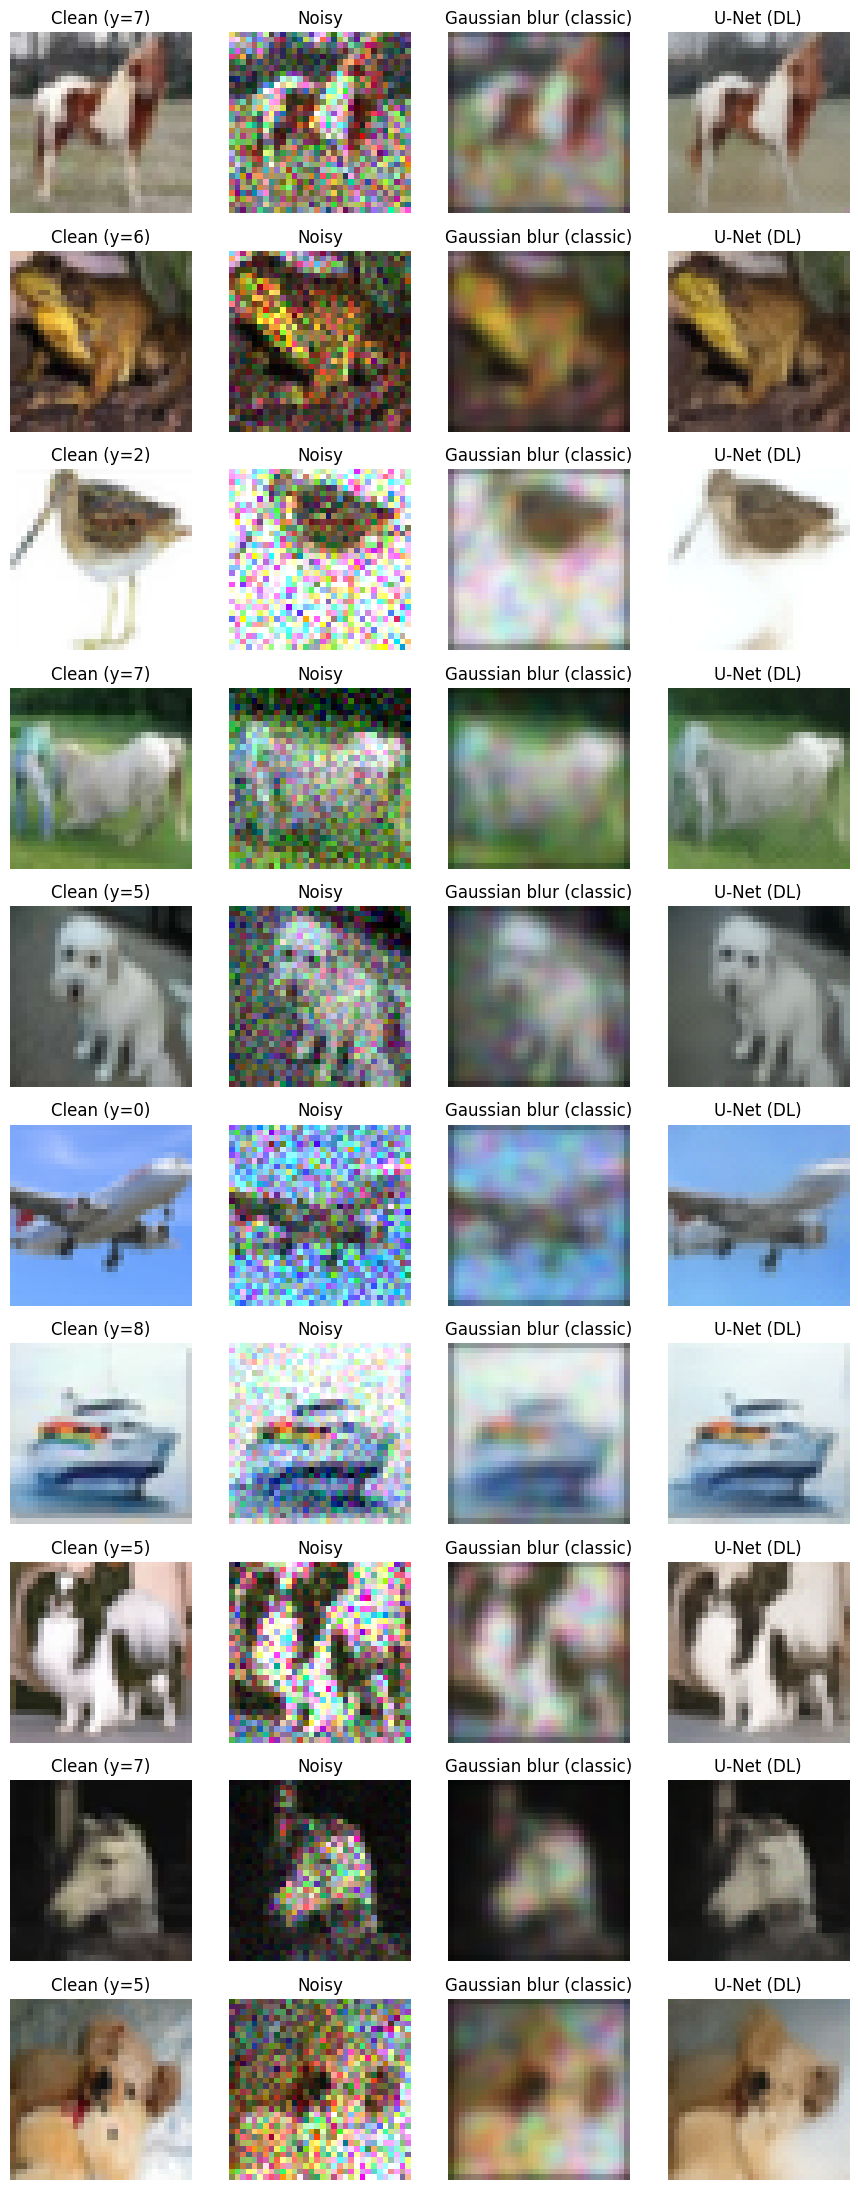

In [24]:
import os
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ---------- 2) Classical non-DL baseline: Gaussian blur via conv2d ----------
def gaussian_kernel2d(kernel_size: int = 7, sigma: float = 1.2, device="cpu", dtype=torch.float32):
    """
    Returns a (1,1,ks,ks) Gaussian kernel normalized to sum=1.
    """
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd")
    ax = torch.arange(kernel_size, device=device, dtype=dtype) - kernel_size // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel.view(1, 1, kernel_size, kernel_size)

@torch.no_grad()
def gaussian_blur_conv(x: torch.Tensor, kernel_size: int = 7, sigma: float = 1.2) -> torch.Tensor:
    """
    x: (B,C,H,W) in [0,1]
    Applies same Gaussian blur independently to each channel.
    """
    device = x.device
    dtype = x.dtype
    k = gaussian_kernel2d(kernel_size, sigma, device=device, dtype=dtype)  # (1,1,ks,ks)
    C = x.shape[1]
    k = k.repeat(C, 1, 1, 1)  # (C,1,ks,ks)
    pad = kernel_size // 2
    return F.conv2d(x, k, padding=pad, groups=C).clamp(0, 1)

# ---------- 3) Paths ----------
out_dir = cfg.out_dir
best_ckpt_path = os.path.join(out_dir, "best_model.pt")
if not os.path.exists(best_ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {best_ckpt_path}")

# ---------- 4) Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- 5) Load checkpoint ----------
base_ch = cfg.base_ch
model = UNetLightGNResidual(base_ch=base_ch, gn_groups=cfg.gn_groups).to(device)

ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint: {best_ckpt_path} (epoch {ckpt['epoch']+1}, best test loss={ckpt['best_test_loss']:.6f})")

tfm = transforms.ToTensor()
test_base = datasets.CIFAR10(cfg.data_dir, train=False, download=True, transform=tfm)

noises = cfg.noises
split_mode = cfg.split_mode
gauss_std = cfg.gaussian_std
speck_std = cfg.speckle_std

test_ds = NoisedCIFAR10(test_base, noises=noises, split_mode=split_mode,
                        gaussian_std=gauss_std, speckle_std=speck_std)

vis_loader = DataLoader(test_ds, batch_size=10, shuffle=True,
                        num_workers=0, pin_memory=(device.type == "cuda"))

# ---------- 7) Get one batch ----------
noisy, clean, labels = next(iter(vis_loader))

# DL denoising
with torch.no_grad():
    denoised_dl = model(noisy.to(device)).cpu()

# Classical baseline (Gaussian blur) - run on CPU tensors (or GPU if you move noisy)
with torch.no_grad():
    # If you want it on GPU: noisy.to(device) then .cpu() afterwards
    denoised_blur = gaussian_blur_conv(noisy, kernel_size=7, sigma=1.2)

# ---------- 8) Plot: N rows, 4 columns (Clean / Noisy / Blur / UNet) ----------
def chw_to_hwc(x):
    return x.permute(1, 2, 0).clamp(0, 1)

N = noisy.size(0)
fig, axes = plt.subplots(N, 4, figsize=(9, 2.2 * N))

for i in range(N):
    axes[i, 0].imshow(chw_to_hwc(clean[i]))
    axes[i, 0].set_title(f"Clean (y={int(labels[i])})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(chw_to_hwc(noisy[i]))
    axes[i, 1].set_title("Noisy")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(chw_to_hwc(denoised_blur[i]))
    axes[i, 2].set_title("Gaussian blur (classic)")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(chw_to_hwc(denoised_dl[i]))
    axes[i, 3].set_title("U-Net (DL)")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()


# Quantitative evaluation script

In [25]:
import torch
import torch.nn.functional as F
import numpy as np

model.eval()

mse_model_total = 0.0
mse_identity_total = 0.0

mse_model_gauss = 0.0
mse_model_speckle = 0.0

n_total = 0
n_gauss = 0
n_speckle = 0

split_index = len(test_loader.dataset) // 2

with torch.no_grad():
    for batch_idx, (noisy, clean, _) in enumerate(test_loader):

        noisy = noisy.to(device)
        clean = clean.to(device)

        # Model output
        denoised = model(noisy)

        # MSEs
        mse_model = F.mse_loss(denoised, clean, reduction="mean")
        mse_identity = F.mse_loss(noisy, clean, reduction="mean")

        mse_model_total += mse_model.item()
        mse_identity_total += mse_identity.item()

        batch_start_idx = batch_idx * test_loader.batch_size
        batch_end_idx = batch_start_idx + noisy.size(0)

        if batch_end_idx <= split_index:
            mse_model_gauss += mse_model.item()
            n_gauss += 1
        elif batch_start_idx >= split_index:
            mse_model_speckle += mse_model.item()
            n_speckle += 1
        else:
            half = split_index - batch_start_idx
            if half > 0:
                mse_model_gauss += F.mse_loss(
                    denoised[:half], clean[:half], reduction="mean"
                ).item()
                n_gauss += 1
            if noisy.size(0) - half > 0:
                mse_model_speckle += F.mse_loss(
                    denoised[half:], clean[half:], reduction="mean"
                ).item()
                n_speckle += 1

        n_total += 1

# Averages
mse_model_total /= n_total
mse_identity_total /= n_total

mse_model_gauss /= max(n_gauss, 1)
mse_model_speckle /= max(n_speckle, 1)

def psnr_from_mse(mse):
    return 10.0 * np.log10(1.0 / max(mse, 1e-12))

# PSNR
psnr_model_total = psnr_from_mse(mse_model_total)
psnr_identity_total = psnr_from_mse(mse_identity_total)

psnr_model_gauss = psnr_from_mse(mse_model_gauss)
psnr_model_speckle = psnr_from_mse(mse_model_speckle)


print("\n========== Quantitative Evaluation ==========\n")

print("Overall:")
print(f"Model     -> MSE: {mse_model_total:.6f} | PSNR: {psnr_model_total:.2f} dB")
print(f"Identity  -> MSE: {mse_identity_total:.6f} | PSNR: {psnr_identity_total:.2f} dB")

print("\nGaussian noise:")
print(f"Model     -> MSE: {mse_model_gauss:.6f} | PSNR: {psnr_model_gauss:.2f} dB")

print("\nSpeckle noise:")
print(f"Model     -> MSE: {mse_model_speckle:.6f} | PSNR: {psnr_model_speckle:.2f} dB")

print("\nPSNR gain over identity (overall): "
      f"{psnr_model_total - psnr_identity_total:.2f} dB")



========== Quantitative Evaluation ==========

Overall:
Model     -> MSE: 0.002247 | PSNR: 26.48 dB
Identity  -> MSE: 0.020401 | PSNR: 16.90 dB

Gaussian noise:
Model     -> MSE: 0.001899 | PSNR: 27.22 dB

Speckle noise:
Model     -> MSE: 0.002578 | PSNR: 25.89 dB

PSNR gain over identity (overall): 9.58 dB
